
DOWNLOAD NCBI

( "Solanum lycopersicum"[Organism] OR "Nicotiana benthamiana"[Organism] )
AND  ( CDS  OR protein OR coding sequence OR mRNA )
AND
( "CNL"
OR "TNL"
OR "RLK"
OR "RLP"
OR "LECRK"
OR LYK"
OR "NBS-LRR"
OR "NB-LRR"
OR plant resistance gene"
OR "immune receptor"
OR "viral resistance"
OR "Tobamovirus"
OR "Potyvírus"
OR "Tospovírus"
OR "Crinivírus"
OR "Cucumovírus"
OR "Alfamovírus"
OR "Sobemovírus"
OR "ToBRFV"
OR "TMV"
OR "PVY"
OR "PepYMV"
OR "TSWV"
OR "GRSV"
OR "ToCV"
OR "CMV"
OR "TMV"
OR "ToMV"
OR "RNA silencing"
OR "hypersensitive response"
)
NOT
(partial
OR hypothetical
OR predicted
OR genome
OR scaffold
OR contig
OR assembly
OR "other RNA" 
OR "non-coding RNA" 
OR "ncRNA" 
OR "lncRNA" 
OR "misc_RNA" 
OR "antisense RNA" 
OR "small RNA" 
OR "miRNA" 
OR "siRNA" 
OR "snoRNA" 
OR "snRNA" 
)

IDs encontrados: 1500
Arquivo salvo: arquivos/positive.fasta

DOWNLOAD NCBI

(
"Solanum lycopersicum"[Organism]
OR
"Nicotiana benthamiana"[Organism]
)
AND
(
transcriptome
OR
mRNA
OR
RNA-Seq


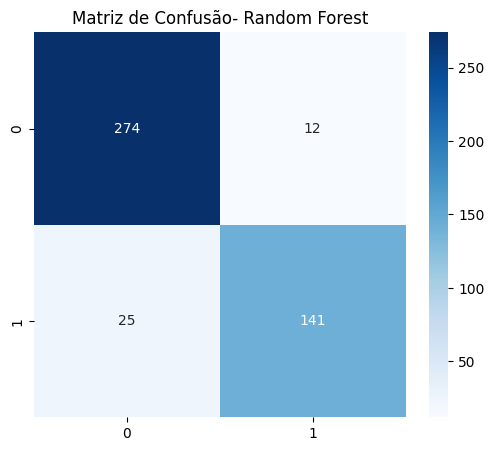

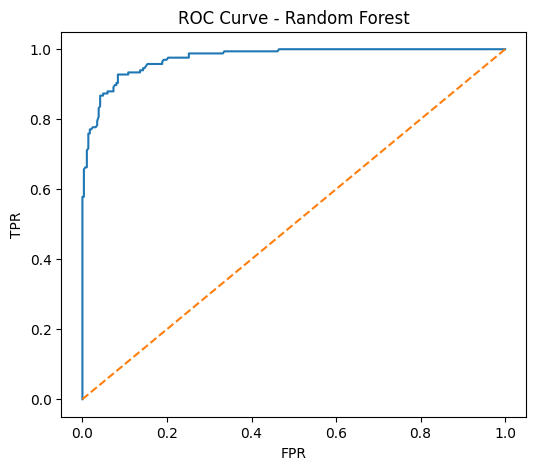



XGBoost
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       286
           1       0.90      0.89      0.90       166

    accuracy                           0.92       452
   macro avg       0.92      0.92      0.92       452
weighted avg       0.92      0.92      0.92       452

ROC-AUC: 0.9818855842952229
PR-AUC : 0.971050615226751
MCC    : 0.8377778363527343
F1     : 0.896969696969697


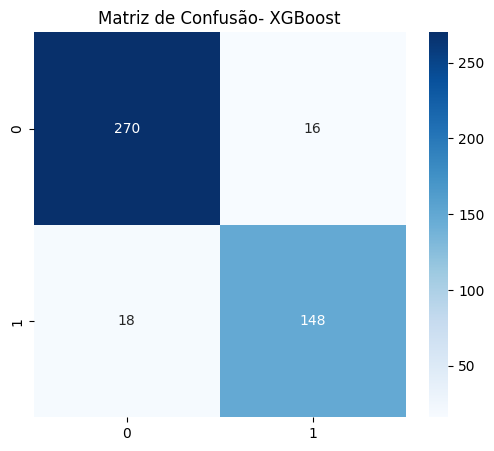

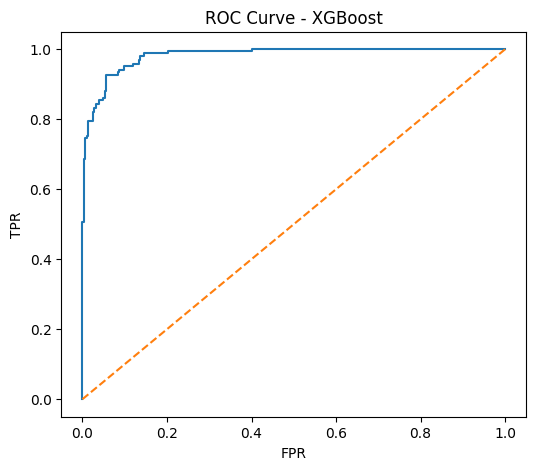


RF ROC-AUC: 0.9717657789454066
XGB ROC-AUC: 0.9801101673062244


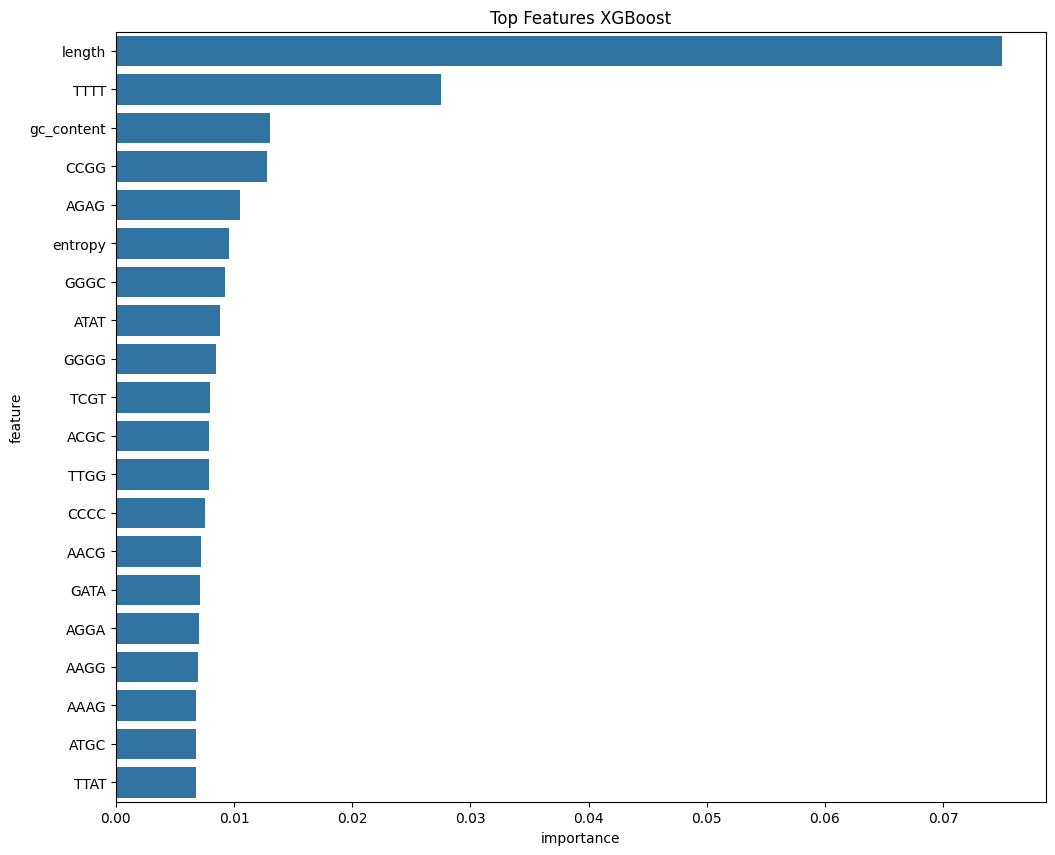


DOWNLOAD NCBI

"Physalis peruviana"[Organism]
AND
(
transcriptome
OR
mRNA
OR
RNA-Seq
)

IDs encontrados: 1000
Arquivo salvo: arquivos/physalis.fasta

DOWNLOAD NCBI

"Arabidopsis thaliana"[Organism]
AND
(
transcriptome
OR
mRNA
OR
RNA-Seq
OR
CDS
OR
transcript
OR
cDNA
)

IDs encontrados: 1000


In [ ]:
import os
import itertools
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from Bio import Entrez
from Bio import SeqIO
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    matthews_corrcoef,
    f1_score,
    silhouette_score,
    davies_bouldin_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import umap
import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns

Entrez.email = "marcela.leite@ifc.edu.br"

OUTPUT_DIR = "arquivos"

os.makedirs(OUTPUT_DIR, exist_ok=True)

def baixar_fasta_ncbi(query, arquivo_saida, max_records=1500):

    print("\n===================================")
    print("DOWNLOAD NCBI")
    print("===================================")

    print(query)

    handle = Entrez.esearch(
        db="nucleotide",
        term=query,
        retmax=max_records
    )

    record = Entrez.read(handle)

    ids = record["IdList"]

    print("IDs encontrados:", len(ids))

    if len(ids) == 0:
        return

    handle = Entrez.efetch(
        db="nucleotide",
        id=ids,
        rettype="fasta",
        retmode="text"
    )

    fasta = handle.read()

    with open(arquivo_saida, "w") as f:
        f.write(fasta)

    print("Arquivo salvo:", arquivo_saida)

# ==========================================================
# QUERY POSITIVA
# ==========================================================

positive_query = """
( "Solanum lycopersicum"[Organism] OR "Nicotiana benthamiana"[Organism] )
AND  ( CDS  OR protein OR coding sequence OR mRNA )
AND
( "CNL"
OR "TNL"
OR "RLK"
OR "RLP"
OR "LECRK"
OR LYK"
OR "NBS-LRR"
OR "NB-LRR"
OR plant resistance gene"
OR "immune receptor"
OR "viral resistance"
OR "Tobamovirus"
OR "Potyvírus"
OR "Tospovírus"
OR "Crinivírus"
OR "Cucumovírus"
OR "Alfamovírus"
OR "Sobemovírus"
OR "ToBRFV"
OR "TMV"
OR "PVY"
OR "PepYMV"
OR "TSWV"
OR "GRSV"
OR "ToCV"
OR "CMV"
OR "TMV"
OR "ToMV"
OR "RNA silencing"
OR "hypersensitive response"
)
NOT
(partial
OR hypothetical
OR predicted
OR genome
OR scaffold
OR contig
OR assembly
OR "other RNA" 
OR "non-coding RNA" 
OR "ncRNA" 
OR "lncRNA" 
OR "misc_RNA" 
OR "antisense RNA" 
OR "small RNA" 
OR "miRNA" 
OR "siRNA" 
OR "snoRNA" 
OR "snRNA" 
)
"""

# ==========================================================
# QUERY NEGATIVA
# ==========================================================

negative_query = """
(
"Solanum lycopersicum"[Organism]
OR
"Nicotiana benthamiana"[Organism]
)
AND
(
transcriptome
OR
mRNA
OR
RNA-Seq
)
AND
(
"actin"
OR
"tubulin"
OR
"ribosomal protein"
OR
"photosystem"
OR
"ATP synthase"
OR
"metabolic enzyme"
)
NOT
(
"resistance"
OR
"NBS"
OR
"LRR"
OR
"immune"
OR
"virus"
)
"""

# ==========================================================
# DOWNLOADS
# ==========================================================

baixar_fasta_ncbi(
    positive_query,
    f"{OUTPUT_DIR}/positive.fasta"
)

baixar_fasta_ncbi(
    negative_query,
    f"{OUTPUT_DIR}/negative.fasta"
)

# ==========================================================
# K-MERS
# ==========================================================

K = 4

NUCLEOTIDES = ['A','T','C','G']

ALL_KMERS = [
    ''.join(p)
    for p in itertools.product(NUCLEOTIDES, repeat=K)
]

# ==========================================================
# LIMPEZA
# ==========================================================
def limpar_seq(seq):
    seq = seq.upper()
    valid = set("ATCG")
    seq = "".join([
        x for x in seq
        if x in valid
    ])

    return seq

# ==========================================================
# GC
# ==========================================================

def calcular_gc(seq):
    gc = seq.count("G") + seq.count("C")
    return gc / len(seq)

# ==========================================================
# ENTROPIA
# ==========================================================

def calcular_entropia(seq):
    probs = []
    for n in "ATCG":
        p = seq.count(n) / len(seq)
        if p > 0:
            probs.append(p)

    entropy = -sum([
        p * np.log2(p)
        for p in probs
    ])

    return entropy

# ==========================================================
# K-MERS
# ==========================================================

def contar_kmers(seq, k=4):
    counts = dict.fromkeys(ALL_KMERS, 0)
    total = len(seq) - k + 1
    if total <= 0:
        return [0]*len(ALL_KMERS)
    for i in range(total):
        kmer = seq[i:i+k]
        if kmer in counts:
            counts[kmer] += 1
    freqs = [
        counts[k]/total
        for k in ALL_KMERS
    ]

    return freqs

# ==========================================================
# FEATURES
# ==========================================================

def extract_features(seq):
    seq = limpar_seq(seq)
    if len(seq) < 300:
        return None
    try:
        kmers = contar_kmers(seq)
        gc = calcular_gc(seq)
        entropy = calcular_entropia(seq)
        length = len(seq)
        return kmers + [
            gc,
            entropy,
            length
        ]
    except:
        return None

# ==========================================================
# DATASET
# ==========================================================

X = []
y = []
ids = []

def processar_fasta(fasta, label):
    total = 0
    validas = 0

    for record in SeqIO.parse(fasta, "fasta"):
        total += 1
        desc = record.description.lower()
        if "partial" in desc:
            continue
        seq = str(record.seq)
        feats = extract_features(seq)
        if feats is not None:
            X.append(feats)
            y.append(label)
            ids.append(record.id)
            validas += 1

    print("\nArquivo:", fasta)
    print("Total:", total)
    print("Válidas:", validas)

# ==========================================================
# PROCESSAMENTO
# ==========================================================

processar_fasta(
    f"{OUTPUT_DIR}/positive.fasta",
    1
)

processar_fasta(
    f"{OUTPUT_DIR}/negative.fasta",
    0
)

# ==========================================================
# ARRAYS
# ==========================================================

X = np.array(X)
y = np.array(y)
print("\nDataset:", X.shape)
if len(X) == 0:
    raise ValueError("Nenhuma sequência válida.")

# ==========================================================
# DATAFRAME
# ==========================================================

columns = ALL_KMERS + [
    "gc_content",
    "entropy",
    "length"
]

df = pd.DataFrame(X, columns=columns)

df["label"] = y

df["id"] = ids

df.to_csv(
    f"{OUTPUT_DIR}/dataset_rgenes.csv",
    index=False
)

# ==========================================================
# TRAIN TEST
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

# ==========================================================
# RANDOM FOREST
# ==========================================================

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

# ==========================================================
# XGBOOST
# ==========================================================

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

# ==========================================================
# AVALIAÇÃO
# ==========================================================

def avaliar_modelo(nome, y_true, pred, prob):

    print("\n")
    print("="*60)
    print(nome)
    print("="*60)

    print(classification_report(y_true, pred))
    auc = roc_auc_score(y_true, prob)
    pr_auc = average_precision_score(y_true, prob)
    mcc = matthews_corrcoef(y_true, pred)
    f1 = f1_score(y_true, pred)

    print("ROC-AUC:", auc)
    print("PR-AUC :", pr_auc)
    print("MCC    :", mcc)
    print("F1     :", f1)

    # ==========================================
    # MATRIZ CONFUSÃO
    # ==========================================

    cm = confusion_matrix(y_true, pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Matriz de Confusão- {nome}")
    plt.show()

    # ==========================================
    # ROC
    # ==========================================

    fpr, tpr, _ = roc_curve(y_true, prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"ROC Curve - {nome}")
    plt.show()

avaliar_modelo(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

avaliar_modelo(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

# ==========================================================
# CROSS VALIDATION
# ==========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_rf = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

scores_xgb = cross_val_score(
    xgb,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("\nRF ROC-AUC:", scores_rf.mean())
print("XGB ROC-AUC:", scores_xgb.mean())

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

importance = pd.DataFrame({
    "feature": columns,
    "importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

importance.to_csv(
    f"{OUTPUT_DIR}/feature_importance.csv",
    index=False
)

plt.figure(figsize=(12,10))
sns.barplot(
    data=importance.head(20),
    x="importance",
    y="feature"
)

plt.title("Top Features XGBoost")
plt.show()

# ==========================================================
# PHYSALIS
# ==========================================================

physalis_query = """
"Physalis peruviana"[Organism]
AND
(
transcriptome
OR
mRNA
OR
RNA-Seq
)
"""

baixar_fasta_ncbi(
    physalis_query,
    f"{OUTPUT_DIR}/physalis.fasta",
    1000
)

#########################################################

arabidopsis_query = """
"Arabidopsis thaliana"[Organism]
AND
(
transcriptome
OR
mRNA
OR
RNA-Seq
OR
CDS
OR
transcript
OR
cDNA
)
"""

baixar_fasta_ncbi(
    arabidopsis_query,
    f"{OUTPUT_DIR}/arabidopsis.fasta",
    1000
)

########################################################

# ==========================================================
# PREDIÇÃO PHYSALIS
# ==========================================================

resultados = []

# for record in SeqIO.parse(
#     f"{OUTPUT_DIR}/physalis.fasta",
#     "fasta"
# ):

for record in SeqIO.parse(
    f"{OUTPUT_DIR}/arabidopsis.fasta",
    "fasta"
):
    seq = str(record.seq)
    feats = extract_features(seq)
    if feats is None:
        continue

    feats = np.array(feats).reshape(1,-1)
    prob = xgb.predict_proba(feats)[0][1]

    resultados.append({
        "id": record.id,
        "descricao": record.description,
        "probabilidade_resistencia": prob
    })

df_res = pd.DataFrame(resultados)

df_res = df_res.sort_values(
    by="probabilidade_resistencia",
    ascending=False
)

df_res.to_csv(
    # f"{OUTPUT_DIR}/predicoes_physalis.csv",
    f"{OUTPUT_DIR}/predicoes_arabidopsis.csv",
    index=False
)

print("\nTOP CANDIDATOS PHYSALIS")
print(df_res.head(20))

# X_phys = []
# phys_ids = []

 # for record in SeqIO.parse(
 #     f"{OUTPUT_DIR}/physalis.fasta",
 #     "fasta"
 # ):
for record in SeqIO.parse(
     f"{OUTPUT_DIR}/arabidopsis.fasta",
     "fasta"
 ):

     seq = str(record.seq)
     feats = extract_features(seq)
     if feats is None:
         continue
     X_phys.append(feats)
     phys_ids.append(record.id)



print("\nPIPELINE FINALIZADO")

